In [1]:
1.#Realizar un análisis exploratorio de los datos para identificar relaciones entre variables, valores atípicos, tendencias,
etc.
UNAD
Afranio Lozano Palma
Predicción de Enfermedad cardiaca con Regresión Logística
Pasos de la Actividad
Realizar un análisis exploratorio de los datos para identificar relaciones entre variables, valores atípicos, tendencias, etc.
Preprocesar los datos limpiándolos, tratando valores faltantes y transformándolos según sea necesario
Seleccionar las características más relevantes para entrenar el modelo utilizando selección de características
Dividir el dataset en Train y Test para evaluar correctamente el modelo
Entrenar el modelo configurando los diferentes hiperparámetros
Evaluar el desempeño del modelo en el conjunto de Test con métricas como precisión, recall, F1-score, etc
Realizar las diferentes gráficas que permitan visualizar los resultados del modelo.
Interpretar, analizar y documentar los resultados obtenidos
Crear una cuenta en GitHub y cargar los códigos de los modelos diseñados

1.0

In [103]:
#cargar las libreriás necesarias
import pandas as pd  # Manejo y análisis de estructuras de datos
import numpy as np    # Cáulculo numérico y el análisis de datos
import seaborn as sns # Creación de gráficos estadísticos
import matplotlib.pyplot as plt  # Creación de gráficos en dos dimensiones


# Librerías para implementar Modelos de ciencias de datos
from sklearn import metrics 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# Lectura de datos en Phyton y lo cargamos en la variable DataHeart
Datos = pd.read_csv('C:/Heart_desease_clveland/heart_cleveland_upload.csv')

In [3]:
# Identificacionb de datos faltantes 
Datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


In [7]:
# Renombrar todas las columnas 
Datos.columns = [  'Edad', 'Sexo', 'TipoDolorPecho', 'PresiónArterial','NivelColesterol', 'AzúcarSangre','Electrocardiograma','FrecuenciaMáxima','Angina','Depresión','Pendiente','NúmeroVasos','Talasemia','PresenciaEnfermedadCardiaca']

In [15]:
# Comprobación de los cambios realizados
print(Datos.head())

   Edad  Sexo  TipoDolorPecho  PresiónArterial  NivelColesterol  \
0    69     1               0              160              234   
1    69     0               0              140              239   
2    66     0               0              150              226   
3    65     1               0              138              282   
4    64     1               0              110              211   

   AzúcarSangre   Electrocardiograma  FrecuenciaMáxima  Angina  Depresión  \
0              1                   2               131       0        0.1   
1              0                   0               151       0        1.8   
2              0                   0               114       0        2.6   
3              1                   2               174       0        1.4   
4              0                   2               144       1        1.8   

   Pendiente  NúmeroVasos  Talasemia  PresenciaEnfermedadCardiaca  
0          1            1          0                            0 

In [61]:
Datos.head(20)

,Edad,Sexo,TipoDolorPecho,PresiónArterial,NivelColesterol,AzúcarSangre,Electrocardiograma,FrecuenciaMáxima,Angina,Depresión,Pendiente,NúmeroVasos,Talasemia,PresenciaEnfermedadCardiaca
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0
5,64,1,0,170,227,0,2,155,0,0.6,1,0,2,0
6,63,1,0,145,233,1,2,150,0,2.3,2,0,1,0
7,61,1,0,134,234,0,0,145,0,2.6,1,2,0,1
8,60,0,0,150,240,0,0,171,0,0.9,0,0,0,0
9,59,1,0,178,270,0,2,145,0,4.2,2,0,2,0


Text(0.5, 1.0, 'Identificación de Datos Faltantes y Atípicos')

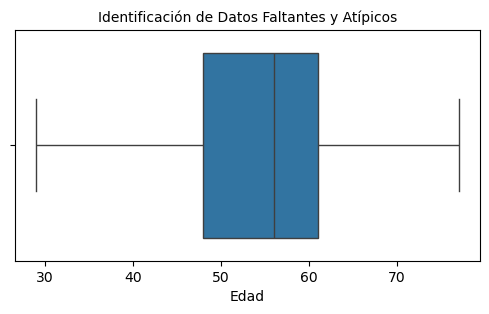

In [9]:
#Identificación de Datos Faltantes y Atípicos para la variable Edad

plt.figure(figsize=(6, 3))
sns.boxplot(x=Datos['Edad'])
plt.title('Identificación de Datos Faltantes y Atípicos', fontsize=10 )

Text(0.5, 1.0, 'Identificación de Datos Faltantes y Atípicos')

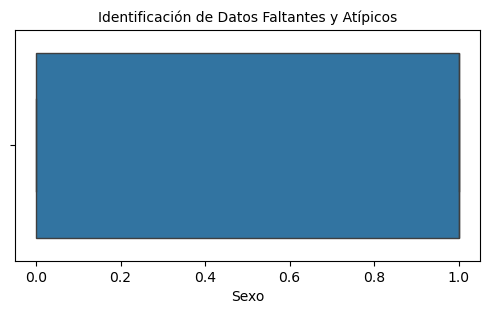

In [11]:
#Identificación de Datos Faltantes y Atípicos para la variable Edad

plt.figure(figsize=(6, 3))
sns.boxplot(x=Datos['Sexo'])
plt.title('Identificación de Datos Faltantes y Atípicos', fontsize=10 )

Text(0.5, 1.0, 'Identificación de Datos Faltantes y Atípicos')

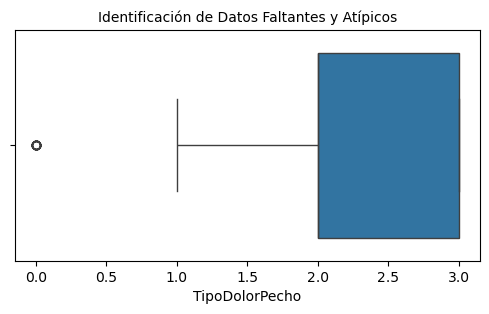

In [13]:
#Identificación de Datos Faltantes y Atípicos para la variable TipoDolorPecho
plt.figure(figsize=(6, 3))
sns.boxplot(x=Datos['TipoDolorPecho'])
plt.title('Identificación de Datos Faltantes y Atípicos', fontsize=10 )

Text(0.5, 1.0, 'Identificación de Datos Faltantes y Atípicos')

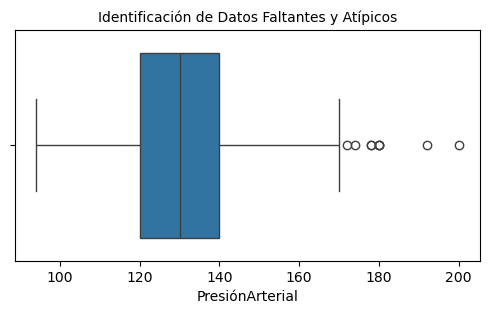

In [15]:
#Identificación de Datos Faltantes y Atípicos para la variable PresiónArterial

plt.figure(figsize=(6, 3))
sns.boxplot(x=Datos['PresiónArterial'])
plt.title('Identificación de Datos Faltantes y Atípicos', fontsize=10 )

Text(0.5, 1.0, 'Identificación de Datos Faltantes y Atípicos')

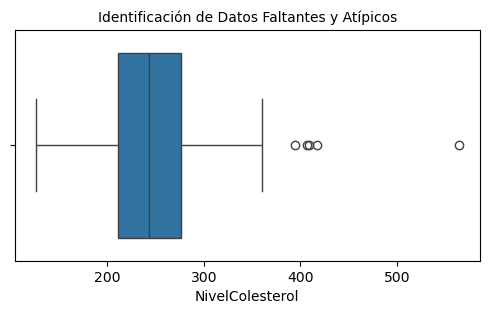

In [17]:
#Identificación de Datos Faltantes y Atípicos para la variable NivelColesterol

plt.figure(figsize=(6, 3))
sns.boxplot(x=Datos['NivelColesterol'])
plt.title('Identificación de Datos Faltantes y Atípicos', fontsize=10 )

Text(0.5, 1.0, 'Identificación de Datos Faltantes y Atípicos')

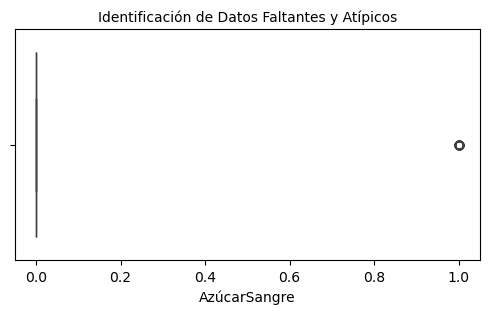

In [19]:
#Identificación de Datos Faltantes y Atípicos para la variable AzúcarSangre

plt.figure(figsize=(6, 3))
sns.boxplot(x=Datos['AzúcarSangre'])
plt.title('Identificación de Datos Faltantes y Atípicos', fontsize=10 )

Text(0.5, 1.0, 'Identificación de Datos Faltantes y Atípicos')

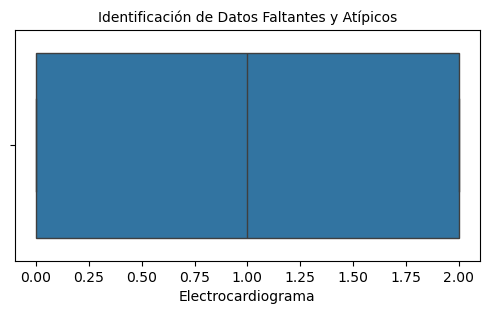

In [21]:
#Identificación de Datos Faltantes y Atípicos para la variableElectrocardiograma

plt.figure(figsize=(6, 3))
sns.boxplot(x=Datos['Electrocardiograma'])
plt.title('Identificación de Datos Faltantes y Atípicos', fontsize=10 )


Text(0.5, 1.0, 'Identificación de Datos Faltantes y Atípicos')

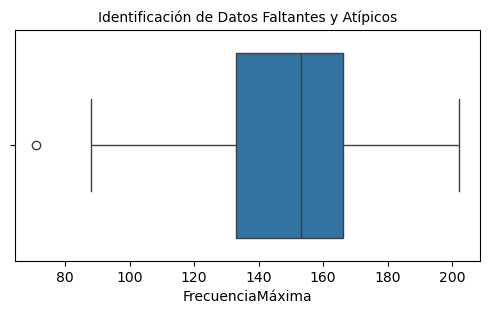

In [23]:
#Identificación de Datos Faltantes y Atípicos para la variable FrecuenciaMáxima
plt.figure(figsize=(6, 3))
sns.boxplot(x=Datos['FrecuenciaMáxima'])
plt.title('Identificación de Datos Faltantes y Atípicos', fontsize=10 )

Text(0.5, 1.0, 'Identificación de Datos Faltantes y Atípicos')

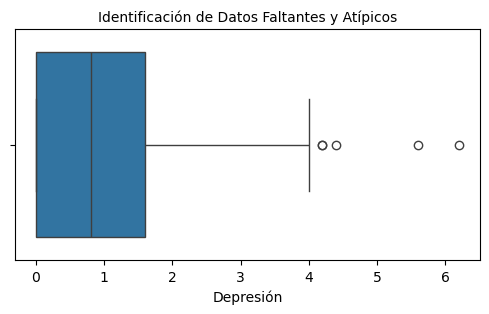

In [25]:
#Identificación de Datos Faltantes y Atípicos para la variable Depresión
plt.figure(figsize=(6, 3))
sns.boxplot(x=Datos['Depresión'])
plt.title('Identificación de Datos Faltantes y Atípicos', fontsize=10 )

Text(0.5, 1.0, 'Identificación de Datos Faltantes y Atípicos')

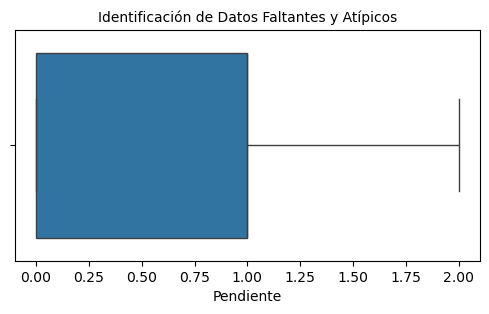

In [27]:
#Identificación de Datos Faltantes y Atípicos para la variable Pendiente ST
plt.figure(figsize=(6, 3))
sns.boxplot(x=Datos['Pendiente'])
plt.title('Identificación de Datos Faltantes y Atípicos', fontsize=10 )

Text(0.5, 1.0, 'Identificación de Datos Faltantes y Atípicos')

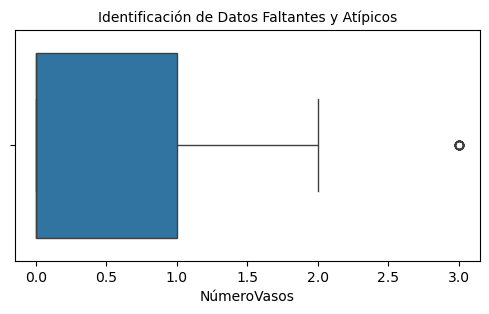

In [35]:
#Identificación de Datos Faltantes y Atípicos para la variable NúmeroVasos
plt.figure(figsize=(6, 3))
sns.boxplot(x=Datos['NúmeroVasos'])
plt.title('Identificación de Datos Faltantes y Atípicos', fontsize=10 )

Text(0.5, 1.0, 'Identificación de Datos Faltantes y Atípicos')

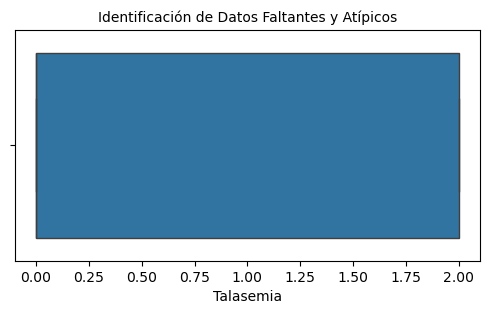

In [29]:
#Identificación de Datos Faltantes y Atípicos para la variable Talasemia
plt.figure(figsize=(6, 3))
sns.boxplot(x=Datos['Talasemia'])
plt.title('Identificación de Datos Faltantes y Atípicos', fontsize=10 )

In [31]:
Datos[Datos['Depresión'] > 5]

,Edad,Sexo,TipoDolorPecho,PresiónArterial,NivelColesterol,AzúcarSangre,Electrocardiograma,FrecuenciaMáxima,Angina,Depresión,Pendiente,NúmeroVasos,Talasemia,PresenciaEnfermedadCardiaca
186,62,0,3,160,164,0,2,145,0,6.2,2,3,2,1
239,55,1,3,140,217,0,0,111,1,5.6,2,0,2,1


In [33]:
# Mostrar los registros mayores a 5 para aplicar la corrección.
print("Cantidad de registros de Depresión mayores a 5 es : ", (Datos['Depresión'] > 5).sum())

Cantidad de registros de Depresión mayores a 5 es :  2


In [35]:
# Corrección de los datos hallados aplicando la Media
media = Datos['Depresión'] .mean()
Datos.loc[Datos['Depresión'] > 5, 'Depresión'] = media

In [37]:
# Mostrar la corrección.
print("Cantidad de registros de Depresión mayores a 5 es : ", (Datos['Depresión'] > 5).sum())

Cantidad de registros de Depresión mayores a 5 es :  0


In [19]:
Datos.describe()

,Edad,Sexo,TipoDolorPecho,PresiónArterial,NivelColesterol,AzúcarSangre,Electrocardiograma,FrecuenciaMáxima,Angina,Depresión,Pendiente,NúmeroVasos,Talasemia,PresenciaEnfermedadCardiaca
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,2.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.022933,0.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.095260,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,4.400000,2.000000,3.000000,2.000000,1.000000


In [39]:
# Calcular datos atípicos de la columna PresiónArterial, utlizando el rango intercuartílico.
columna = 'PresiónArterial' 
Q1 = Datos[columna].quantile(0.25)
Q3 = Datos[columna].quantile(0.75)
IQR = Q3 - Q1

In [25]:
# Detectar valores atípicos para la PresiónArterial
outliers = Datos[(Datos[columna] < Q1 - 1.5 * IQR) | (Datos[columna] > Q3 + 1.5 * IQR)]
print("Valores atípicos:")
print(outliers)

Valores atípicos:
     Edad  Sexo  TipoDolorPecho  PresiónArterial  NivelColesterol  \
9      59     1               0              178              270   
45     54     1               1              192              283   
76     68     1               2              180              274   
117    52     1               2              172              199   
167    66     0               3              178              228   
178    64     0               3              180              325   
209    59     0               3              174              249   
234    56     0               3              200              288   
242    55     0               3              180              327   

     AzúcarSangre   Electrocardiograma  FrecuenciaMáxima  Angina  Depresión  \
9                0                   2               145       0        4.2   
45               0                   2               195       0        0.0   
76               1                   2               1

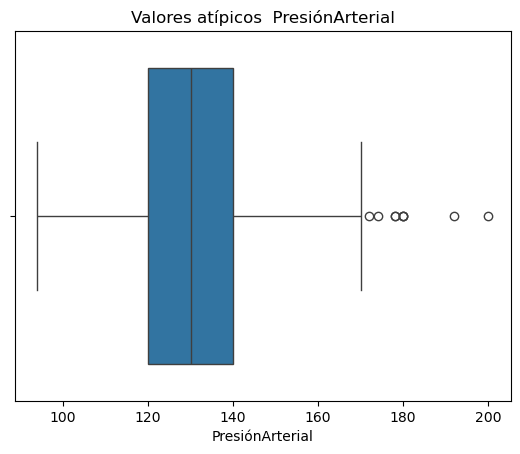

In [41]:
sns.boxplot(x=Datos[columna])
plt.title(f"Valores atípicos  {columna}")
plt.show()

Text(0.5, 1.0, 'Identificación de datos Faltantes y Atípicos')

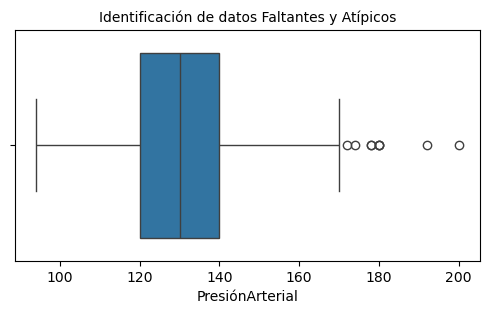

In [43]:
# Identificación de datos faltantes y atípicos
plt.figure(figsize= (6,3))
sns.boxplot(x=Datos['PresiónArterial'])
plt.title('Identificación de datos Faltantes y Atípicos', fontsize=10 ) 

In [45]:
#Preprocesar los datos limpiándolos, tratando valores faltantes y transformándolos según sea necesario.
# Revisión de datos faltantes
print ("Cantidad de Registros con cero en Nivel de PresiónArterial: ", Datos['PresiónArterial'].isin([0]).sum())

Cantidad de Registros con cero en Nivel de PresiónArterial:  0


In [47]:
PresiónArterial = Datos['PresiónArterial']

In [49]:
# Calcular Q1 y Q3
Q1 = PresiónArterial.quantile(0.25)
Q3 = PresiónArterial.quantile(0.75)
IQR = Q3 - Q1

In [51]:
# Límites inferior y superior
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [53]:
# Detectar valores atípicos
outliers = PresiónArterial[(PresiónArterial < lower_bound) | (PresiónArterial > upper_bound)]


In [55]:
# Mostrar valores atípicos, mínimo y máximo
print("Valores atípicos:")
print(outliers)

Valores atípicos:
9      178
45     192
76     180
117    172
167    178
178    180
209    174
234    200
242    180
Name: PresiónArterial, dtype: int64


In [50]:
print("\nValor mínimo en 'PresiónArterial':", PresiónArterial.min())


Valor mínimo en 'PresiónArterial': 94


In [52]:
print("Valor máximo en 'PresiónArterial':", PresiónArterial.max())

Valor máximo en 'PresiónArterial': 200


In [54]:
# Conteo de Datos Atípicos para la PresiónArterial
nivel_minimo=94
nivel_maximo=200
Total_Atipicos=((Datos['PresiónArterial']<nivel_minimo) | (Datos['PresiónArterial']> nivel_maximo)).sum()
print("El total de datos Atipicos es {}".format(Total_Atipicos))

El total de datos Atipicos es 0


In [57]:
# Conteo de Datos Atípicos para la FrecuenciaCardiacaMaxima
nivel_minimo=71
nivel_maximo=202
Total_Atipicos=((Datos['FrecuenciaMáxima']<nivel_minimo) | (Datos['FrecuenciaMáxima']> nivel_maximo)).sum()
print("El total de datos Atipicos es {}".format(Total_Atipicos))

El total de datos Atipicos es 0


In [ ]:
#Corrección de los valores atípicos para la variable PresiónArterial utilizando la media y redondeo 

In [59]:
media = round(Datos['PresiónArterial'].mean())
Datos.loc[Datos['PresiónArterial'] > 185, 'PresiónArterial'] = media
Datos.loc[Datos['PresiónArterial'] < 85, 'PresiónArterial'] = media
print("El Total de datos de PresiónArterial mayores a 185 es=", (Datos['PresiónArterial'] > 185).sum())
print("El Total de datos de PresiónArterial menores a 85 es=", (Datos['PresiónArterial'] < 85).sum())

El Total de datos de PresiónArterial mayores a 185 es= 0
El Total de datos de PresiónArterial menores a 85 es= 0


In [63]:
Datos['PresenciaEnfermedadCardiaca'].value_counts()

PresenciaEnfermedadCardiaca
0    160
1    137
Name: count, dtype: int64

In [65]:
Datos[['PresenciaEnfermedadCardiaca']].head(30)

,PresenciaEnfermedadCardiaca
0,0
1,0
2,0
3,1
4,0
5,0
6,0
7,1
8,0
9,0


In [81]:
# Porcentaje de datos para entrenamiento (train) = 75% , y para prueba (test) = 25%

# Se crean variables X y Y para almacenar la información del entrenamiento

X = Datos.drop('PresenciaEnfermedadCardiaca',axis=1) # Se cargan los datos de train sin los datos de la columna PresenciaEnfermedadCardiaca
Y = Datos['PresenciaEnfermedadCardiaca'] # Se cargan los datos de train con los datos de la la columna PresenciaEnfermedadCardiaca
#La función train_test_split crea una división de un conjunto de datos en dos bloques uno de entrenamiento y otro de prueba (train and test)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, stratify=Y, random_state= 0)

In [83]:
print(X_train)

     Edad  Sexo  TipoDolorPecho  PresiónArterial  NivelColesterol  \
234    56     0               3              132              288   
82     66     0               2              146              278   
36     56     1               1              120              240   
237    56     1               3              132              184   
133    47     1               2              108              243   
..    ...   ...             ...              ...              ...   
291    40     1               3              110              167   
195    61     0               3              130              330   
170    65     0               3              150              225   
135    46     0               2              142              177   
293    39     1               3              118              219   

     AzúcarSangre  Electrocardiograma  FrecuenciaMáxima  Angina  Depresión  \
234             1                   2               133       1        4.0   
82             

In [85]:
print (X_test)

     Edad  Sexo  TipoDolorPecho  PresiónArterial  NivelColesterol  \
185    62     0               3              140              268   
157    70     1               3              145              174   
110    54     0               2              135              304   
39     56     1               1              130              221   
198    60     1               3              130              206   
..    ...   ...             ...              ...              ...   
278    45     1               3              115              260   
163    67     1               3              100              299   
137    44     0               2              108              141   
33     57     0               1              130              236   
246    54     1               3              110              239   

     AzúcarSangre  Electrocardiograma  FrecuenciaMáxima  Angina  Depresión  \
185             0                   2               160       0        3.6   
157            

In [ ]:
5. Entrenar el modelo configurando los diferentes hiperparámetros

In [87]:
# Construir el modelo de regresión logística 

modelo_regresion = LogisticRegression(solver = "liblinear") # liblinear es una libreria para resolver problemas lineales de clasificación y regresión
modelo_regresion.fit (X_train , Y_train)   

# Crea el modelo de prediccion
Prediccion = modelo_regresion.predict(X_test) # la función predict predice los valores a partir del conjunto de datos de validación

In [89]:
X_test.head(10)

,Edad,Sexo,TipoDolorPecho,PresiónArterial,NivelColesterol,AzúcarSangre,Electrocardiograma,FrecuenciaMáxima,Angina,Depresión,Pendiente,NúmeroVasos,Talasemia
185,62,0,3,140,268,0,2,160,0,3.6,2,2,0
157,70,1,3,145,174,0,0,125,1,2.6,2,0,2
110,54,0,2,135,304,1,0,170,0,0.0,0,0,0
39,56,1,1,130,221,0,2,163,0,0.0,0,0,2
198,60,1,3,130,206,0,2,132,1,2.4,1,2,2
7,61,1,0,134,234,0,0,145,0,2.6,1,2,0
202,60,1,3,140,293,0,2,170,0,1.2,1,2,2
285,43,1,3,150,247,0,0,171,0,1.5,0,0,0
272,46,0,3,138,243,0,2,152,1,0.0,1,0,0
111,54,1,2,150,232,0,2,165,0,1.6,0,0,2


In [91]:
print (Prediccion)

[1 1 0 0 1 0 1 0 0 1 0 1 1 1 1 1 0 0 0 1 0 1 1 1 0 0 0 0 0 1 0 1 1 0 0 0 0
 0 1 0 0 0 1 1 1 1 1 0 1 1 0 1 0 0 0 0 0 1 1 1 1 0 0 0 1 0 0 1 0 0 0 1 0 0
 1]


In [ ]:
6. Evaluar el desempeño del modelo en el conjunto de Test con métricas como precisión, recall, F1-score, etc

In [97]:
# Desempeño del modelo de regresión

print(classification_report(Y_test,Prediccion))

              precision    recall  f1-score   support

           0       0.88      0.90      0.89        40
           1       0.88      0.86      0.87        35

    accuracy                           0.88        75
   macro avg       0.88      0.88      0.88        75
weighted avg       0.88      0.88      0.88        75



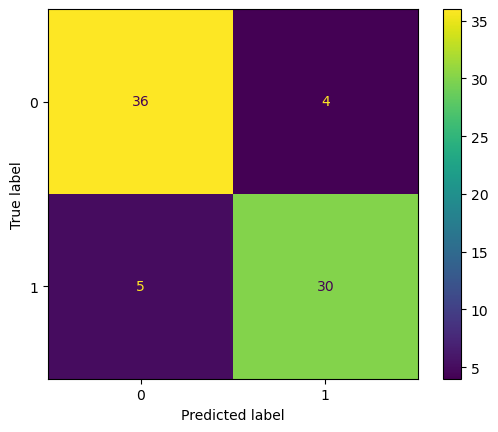

In [107]:
#7. Realizar las diferentes gráficas que permitan visualizar los resultados del modelo
#Matrix de Confusión del modelo

cm=confusion_matrix(Y_test,Prediccion)
disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

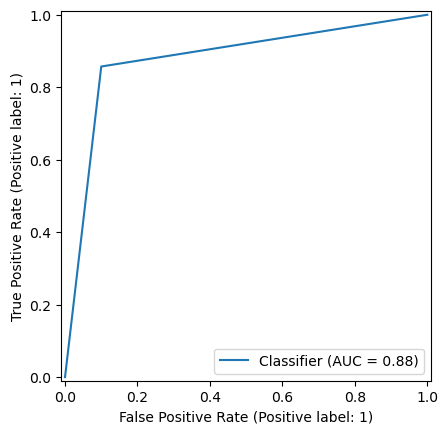

In [109]:
# Curva de precisón del modelo

from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(Y_test, Prediccion)
plt.show()

In [ ]:
#8. Interpretar, analizar y documentar los resultados obtenidos
Del desempeño del modelo se puede describir:

#Precisión: Precisión mide la proporción de predicciones positivas verdaderas entre todas las predicciones positivas realizadas por el modelo.
#Aquí la precisión para la clase "PresenciaEnfermedadCardiaca" es 0,88, lo que significa que el 88% de los predichos con enfermedades cardiacas
#por el modelo eran en realidad personas con la presencia de enfermedades cardiacas.

#Recall: Mide la proporción de predicciones positivas verdaderas entre todas las instancias positivas reales en el conjunto de datos.
#Aquí el Recall para la clase "PresenciaEnfermedadCardiaca" es 0,86, lo que indica que el modelo identificó correctamente al 86% de todos los enfermos cardiovasculares.

F1 Score: Es la media armónica de precisión y recall. Proporciona una puntuación única que equilibra la precisión y recall. 
Aquí la puntuación F1 para la clase PresenciaEnfermedadCardiaca" es 0,87, lo que indica un equilibrio entre precisión y recall.

De la Matriz de Confusión podemos interpretar:

Verdaderos negativos: el recuento de observaciones que un clasificador predijo correctamente como falso 36

Verdaderos positivos: el recuento de observaciones que un clasificador predijo correctamente como Verdadero 30

Falsos positivos: el recuento de observaciones que un clasificador predijo incorrectamente como Verdaderas 4

Falsos negativos: el recuento de observaciones que un clasificador predijo incorrectamente como falso 5

De la curva de precisión del modelo se puede interpretar:

El AUC es 0,88 lo que significa que el 88% de las predicciones del clasificador son correctas en todos los umbrales de clasificación.